Projeto Avaliativo - Desenvolvimento de IA para Análise Preditiva


In [4]:
# Importação das Bibliotecas

import pandas as pd
import numpy as np

# Plotar e criar gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Converter texto para números
from sklearn.preprocessing import LabelEncoder

# Dividir dados em treino e teste
from sklearn.model_selection import train_test_split

# Balanceamento da base
from imblearn.over_sampling import SMOTE

# Padronização dos dados
from sklearn.preprocessing import StandardScaler

# Modelos de Machine Learning (knn e random forest)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Métrica de avaliação
from sklearn.metrics import accuracy_score

In [5]:
# Carregamento da base de dados
df = pd.read_csv("data/manutencao_preditiva.csv")

In [6]:
#  Visualizando as cinco primeiras linhas da base
df.head(5)

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


In [7]:
# # Visualizando os nomes das colunas
df.columns

Index(['udi', 'id_produto', 'tipo', 'temperatura_ar_k',
       'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm',
       'desgaste_ferramenta_min', 'falha_maquina', 'falha_twf', 'falha_hdf',
       'falha_pwf', 'falha_osf', 'falha_rnf'],
      dtype='str')

In [8]:
# Visualizando os valores únicos da coluna "tipo" 
df["tipo"].unique()

<StringArray>
['M', 'L', 'H']
Length: 3, dtype: str

In [9]:
# Visualizando a estrutura da base de dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  str    
 2   tipo                     10000 non-null  str    
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 12  falha_osf                10000 non-null  int64  
 13  falha_rnf                10000 non-null  int64  
dtypes: float64(4), int64(8), str(2)
me

In [10]:
# Removendo colunas de tipos específicos de falha
df = df.drop(columns=[
    "falha_twf",
    "falha_hdf",
    "falha_pwf",
    "falha_osf",
    "falha_rnf"
])

In [11]:
# Verificar a estrutura do DataFrame
df.shape

(10000, 9)

In [12]:
# Verificar estatísticas descritivas
df.describe()

,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


# Fase 1 - Análise Exploratória (EDA)

Nesta etapa são analisadas as características iniciais da base de dados, verificando sua estrutura, dimensões, tipos de dados, estatísticas descritivas e padrões visuais que auxiliam na preparação para o treinamento dos modelos de Machine Learning.

## Histograma da Temperatura do Ar

O histograma permite visualizar a distribuição dos valores da temperatura do ar (K), identificando a concentração dos dados, a dispersão e possíveis assimetrias da variável.

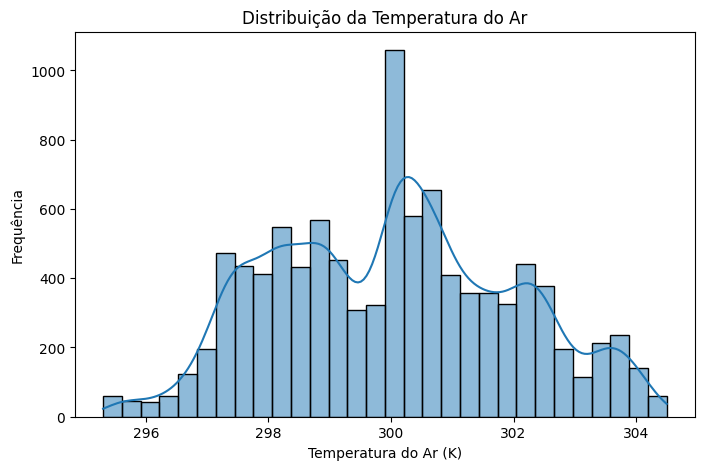

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(df["temperatura_ar_k"], bins=30, kde=True)

plt.title("Distribuição da Temperatura do Ar")
plt.xlabel("Temperatura do Ar (K)")
plt.ylabel("Frequência")
plt.savefig("graficos/distribuicao_temperatura_ar.png", dpi=300, bbox_inches="tight")

plt.show()

### Análise

Análise: O histograma mostra que a temperatura do ar varia aproximadamente entre 295 K e 304 K, com maior concentração de valores entre 297 K e 303 K. Observa-se que a maioria das medições está próxima de 300 K, indicando que essa é a faixa de temperatura mais frequente no conjunto de dados. A distribuição apresenta leve assimetria e mais de um pico na curva de densidade, sugerindo diferentes condições de operação durante a coleta dos dados

# Fase 2 – Limpeza e Tratamento dos Dados

Nesta etapa serão identificados registros duplicados, valores ausentes e possíveis outliers. O objetivo é preparar a base de dados para o treinamento dos modelos de Machine Learning, reduzindo inconsistências que possam comprometer os resultados.

In [14]:
print("Quantidade de registros duplicados:", df.duplicated().sum())

Quantidade de registros duplicados: 0


### Análise

Foi realizada a verificação de registros duplicados utilizando o método `duplicated()`. Não foram identificadas linhas duplicadas na base de dados, portanto não foi necessária a remoção de registros nesta etapa.

In [15]:
# Verificar valores nulos
df.isnull().sum()

udi                          0
id_produto                   0
tipo                         0
temperatura_ar_k           500
temperatura_processo_k     500
velocidade_rotacao_rpm     500
torque_nm                  500
desgaste_ferramenta_min      0
falha_maquina                0
dtype: int64

## Análise dos valores nulos

A verificação dos valores ausentes mostrou que apenas as colunas `temperatura_ar_k`, `temperatura_processo_k`, `velocidade_rotacao_rpm` e `torque_nm` possuem registros nulos, totalizando 500 valores ausentes em cada uma. As demais colunas não apresentam dados faltantes. Esses valores serão tratados na próxima etapa para garantir a qualidade dos dados utilizados no treinamento dos modelos.

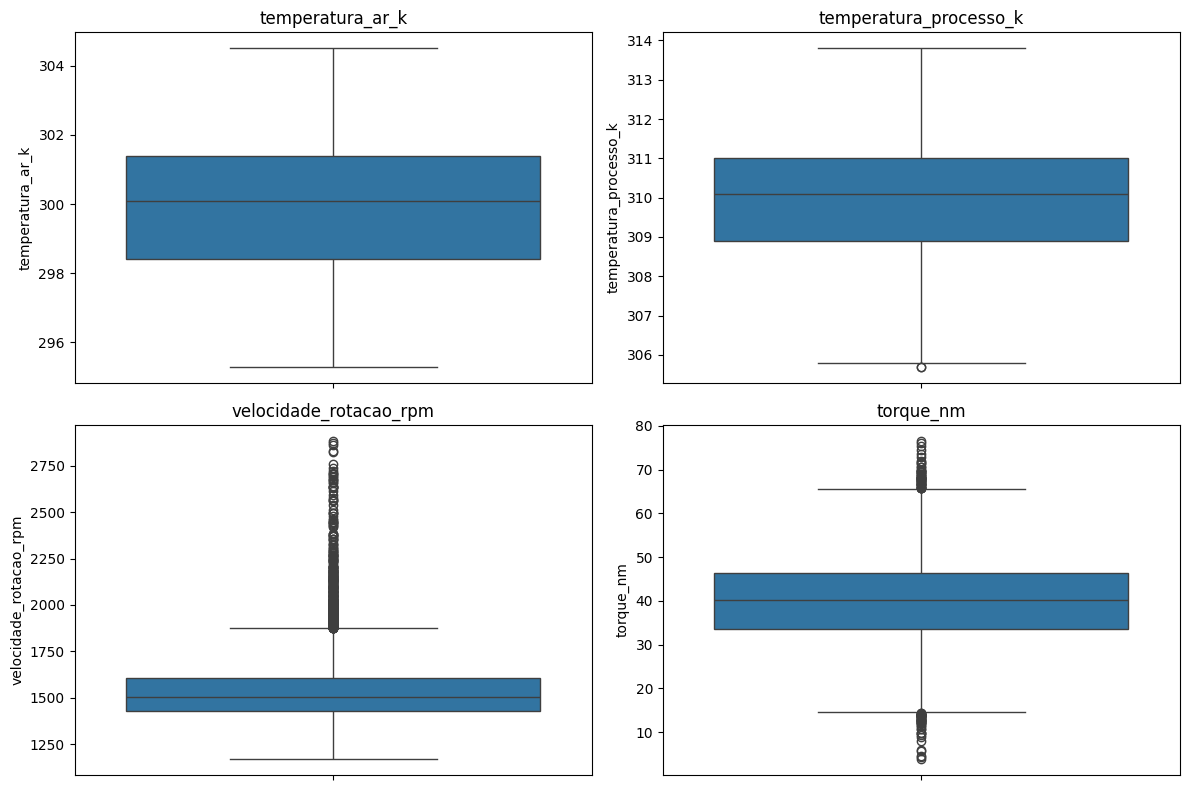

In [48]:
colunas = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm"
]

plt.figure(figsize=(12,8))

for i, coluna in enumerate(colunas, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[coluna])
    plt.title(coluna)
    plt.savefig("graficos/boxplot_torque.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

In [17]:
df["temperatura_ar_k"] = df["temperatura_ar_k"].fillna(df["temperatura_ar_k"].median())

df["temperatura_processo_k"] = df["temperatura_processo_k"].fillna(df["temperatura_processo_k"].median())

df["velocidade_rotacao_rpm"] = df["velocidade_rotacao_rpm"].fillna(df["velocidade_rotacao_rpm"].median())

df["torque_nm"] = df["torque_nm"].fillna(df["torque_nm"].median())

In [18]:
# contar os valores nulos 
df.isnull().sum()

udi                        0
id_produto                 0
tipo                       0
temperatura_ar_k           0
temperatura_processo_k     0
velocidade_rotacao_rpm     0
torque_nm                  0
desgaste_ferramenta_min    0
falha_maquina              0
dtype: int64

### Tratamento dos valores ausentes

Após a análise dos boxplots, verificou-se que as variáveis `velocidade_rotacao_rpm` e `torque_nm` apresentam diversos valores extremos (outliers). Como a média é sensível a esses valores, optou-se por utilizar a **mediana** para preencher os valores ausentes nas quatro variáveis numéricas (`temperatura_ar_k`, `temperatura_processo_k`, `velocidade_rotacao_rpm` e `torque_nm`).

Essa estratégia reduz a influência dos outliers e preserva melhor a tendência central dos dados, tornando a base mais adequada para o treinamento dos modelos de Machine Learning.

# Fase 3 – Engenharia de Atributos (Feature Engineering)

Nesta etapa é criada uma nova variável derivada das informações existentes na base de dados. O objetivo é fornecer aos modelos de Machine Learning uma característica adicional que possa contribuir para melhorar a capacidade de previsão das falhas das máquinas.

In [19]:
# Criando uma nova variável

df["potencia"] = df["velocidade_rotacao_rpm"] * df["torque_nm"]

In [20]:
df[["velocidade_rotacao_rpm",
    "torque_nm",
    "potencia"]].head()

,velocidade_rotacao_rpm,torque_nm,potencia
0,1551.0,42.8,66382.8
1,1408.0,46.3,65190.4
2,1498.0,49.4,74001.2
3,1504.0,40.1,60310.4
4,1408.0,40.0,56320.0


### Análise

Foi criada a variável `potencia`, calculada pela multiplicação da velocidade de rotação (`velocidade_rotacao_rpm`) pelo torque (`torque_nm`).

Essa nova característica representa uma estimativa simplificada da potência mecânica, obtida pela combinação entre velocidade de rotação e torque

In [21]:
labelencoder_tipo = LabelEncoder()

df["tipo"] = labelencoder_tipo.fit_transform(df["tipo"])

# Fase 4 – Separação das Variáveis

Nesta etapa são definidas as variáveis preditoras (X) e a variável alvo (y). A variável alvo corresponde à ocorrência de falha da máquina, enquanto as variáveis preditoras representam as características utilizadas pelos modelos para realizar a previsão.

In [22]:
# Variáveis preditoras
X = df[
    [
        "tipo",
        "temperatura_ar_k",
        "temperatura_processo_k",
        "velocidade_rotacao_rpm",
        "torque_nm",
        "desgaste_ferramenta_min",
        "potencia",
    ]
]

# Variável alvo
y = df["falha_maquina"]

In [23]:
print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (10000, 7)
Formato de y: (10000,)


In [24]:
print(X.head())

   tipo  temperatura_ar_k  temperatura_processo_k  velocidade_rotacao_rpm  \
0     2             298.1                   308.6                  1551.0   
1     1             298.2                   308.7                  1408.0   
2     1             298.1                   308.5                  1498.0   
3     1             300.1                   310.1                  1504.0   
4     1             298.2                   308.7                  1408.0   

   torque_nm  desgaste_ferramenta_min  potencia  
0       42.8                        0   66382.8  
1       46.3                        3   65190.4  
2       49.4                        5   74001.2  
3       40.1                        7   60310.4  
4       40.0                        9   56320.0  


# Fase 5 – Divisão dos Dados

Nesta etapa a base de dados é dividida em conjunto de treinamento e conjunto de teste. Foi utilizada uma proporção de 80% para treinamento e 20% para teste.

O parâmetro `stratify=y` foi utilizado para manter a mesma proporção de máquinas com falha e sem falha nos dois conjuntos, reduzindo o risco de viés durante o treinamento dos modelos.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
# Quantidade de máquinas com e sem falha
print(df["falha_maquina"].value_counts())

falha_maquina
0    9661
1     339
Name: count, dtype: int64


In [27]:
# Percentual de cada classe
print(df["falha_maquina"].value_counts(normalize=True) * 100)

falha_maquina
0    96.61
1     3.39
Name: proportion, dtype: float64


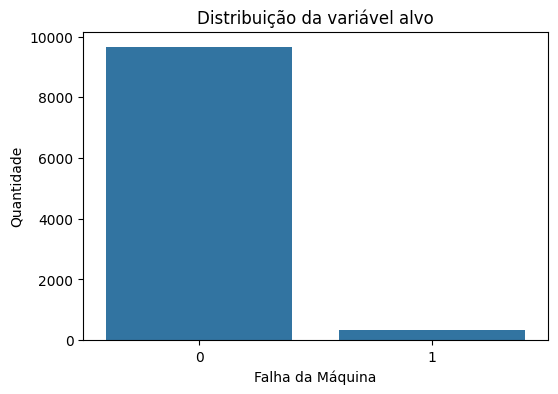

In [49]:
plt.figure(figsize=(6,4))

sns.countplot(x="falha_maquina", data=df)

plt.title("Distribuição da variável alvo")
plt.xlabel("Falha da Máquina")
plt.ylabel("Quantidade")
plt.savefig("graficos/distribuicao_falha.png", dpi=300, bbox_inches="tight")

plt.show()

### Análise da distribuição da variável alvo

O gráfico apresenta a distribuição da variável **falha_maquina**, em que:

- **0** representa máquinas que **não apresentaram falha**.
- **1** representa máquinas que **apresentaram falha**.

Nota-se que a grande maioria dos registros pertence à classe **0**, enquanto a classe **1** possui uma quantidade significativamente menor de observações. Isso indica que o conjunto de dados é **desbalanceado**, ou seja, há muito mais exemplos de máquinas sem falha do que de máquinas com falha.

Esse desbalanceamento é comum em problemas de manutenção preditiva, pois, na prática, as falhas costumam ocorrer com menor frequência do que o funcionamento normal dos equipamentos.

Durante a etapa de modelagem, esse aspecto deve ser considerado, pois modelos treinados em bases desbalanceadas podem apresentar alta acurácia simplesmente por preverem a classe majoritária. Por isso, além da acurácia, é recomendável avaliar métricas como **precisão, revocação (recall)** e **F1-score**, que fornecem uma análise mais completa do desempenho do modelo.

# Fase 6 – Balanceamento da Base

A análise da variável alvo mostrou que a quantidade de máquinas sem falha é muito superior à quantidade de máquinas com falha, caracterizando um desbalanceamento entre as classes.

Para reduzir esse problema, será utilizada a técnica **SMOTE (Synthetic Minority Over-sampling Technique)**, que gera exemplos sintéticos da classe minoritária apenas no conjunto de treinamento. Dessa forma, evita-se que o modelo fique tendencioso para a classe majoritária.

In [29]:
X_train.dtypes

tipo                         int64
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
potencia                   float64
dtype: object

In [30]:
X = df.drop(columns=["udi", "id_produto", "falha_maquina"])
y = df["falha_maquina"]

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
print(X.columns)

Index(['tipo', 'temperatura_ar_k', 'temperatura_processo_k',
       'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min',
       'potencia'],
      dtype='str')


In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["tipo"] = le.fit_transform(df["tipo"])

In [35]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

In [36]:
print("Antes do SMOTE:")
print(y_train.value_counts())

print("\nDepois do SMOTE:")
print(y_train_bal.value_counts())

Antes do SMOTE:
falha_maquina
0    7729
1     271
Name: count, dtype: int64

Depois do SMOTE:
falha_maquina
0    7729
1    7729
Name: count, dtype: int64


### Análise

Após a aplicação do SMOTE, a quantidade de exemplos das duas classes tornou-se equilibrada. Esse procedimento reduz o viés do modelo em favor da classe majoritária e melhora a capacidade de identificar máquinas com falha durante o treinamento.

# Fase 7 – Padronização dos Dados

O algoritmo KNN é baseado no cálculo de distâncias entre os registros. Para evitar que variáveis com valores numéricos maiores tenham maior influência no modelo, foi aplicada a padronização dos dados utilizando o StandardScaler.

Essa etapa foi realizada apenas para o KNN. A Random Forest não necessita de padronização, pois seu funcionamento é baseado em árvores de decisão e não em medidas de distância.

In [37]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_bal)

X_test_scaled = scaler.transform(X_test)

# Fase 8 – Modelo KNN

Nesta etapa foi treinado um modelo K-Nearest Neighbors (KNN), utilizando os dados previamente balanceados com SMOTE e padronizados com StandardScaler.

In [38]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train_bal)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [39]:
# Fazendo as previsões

y_pred_knn = knn.predict(X_test_scaled)

In [40]:
## Avaliando o modelo

from sklearn.metrics import accuracy_score

acuracia_knn = accuracy_score(y_test, y_pred_knn)

print(f"Acurácia do KNN: {acuracia_knn:.4f}")

Acurácia do KNN: 0.8960


In [41]:
for k in [3, 5, 7, 9]:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled, y_train_bal)

    y_pred = knn.predict(X_test_scaled)

    acuracia = accuracy_score(y_test, y_pred)

    print(f"K = {k} -> Acurácia = {acuracia:.4f}")

K = 3 -> Acurácia = 0.9055
K = 5 -> Acurácia = 0.8960
K = 7 -> Acurácia = 0.8885
K = 9 -> Acurácia = 0.8830


### Análise dos resultados do KNN

Foram avaliados quatro valores para o parâmetro `k` (3, 5, 7 e 9). O melhor desempenho foi obtido com `k = 3`, alcançando uma acurácia de **90,55%**.

Nota-se que, à medida que o número de vizinhos aumentou, houve uma pequena redução na acurácia. Dessa forma, o modelo KNN com três vizinhos foi selecionado para comparação com o modelo Random Forest.

# Fase 9 – Modelo Random Forest

Nesta etapa foi treinado um modelo Random Forest utilizando os dados balanceados com SMOTE.

Diferentemente do KNN, esse algoritmo não necessita de padronização dos dados, pois seu funcionamento é baseado em árvores de decisão.

In [42]:
# Criando o modelo

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_bal, y_train_bal)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [43]:
# Fazendo as previsões 

y_pred_rf = rf.predict(X_test)

In [44]:
# avaliando 
 
acuracia_rf = accuracy_score(y_test, y_pred_rf)

print(f"Acurácia Random Forest: {acuracia_rf:.4f}")

Acurácia Random Forest: 0.9430


In [45]:
# Testar parametro 

for profundidade in [3, 5, 10, None]:

    rf = RandomForestClassifier(
        max_depth=profundidade,
        random_state=42
    )

    rf.fit(X_train_bal, y_train_bal)

    y_pred = rf.predict(X_test)

    acuracia = accuracy_score(y_test, y_pred)

    print(f"Profundidade = {profundidade} -> Acurácia = {acuracia:.4f}")

Profundidade = 3 -> Acurácia = 0.8935
Profundidade = 5 -> Acurácia = 0.9095
Profundidade = 10 -> Acurácia = 0.9340
Profundidade = None -> Acurácia = 0.9430


### Análise do modelo Random Forest

Foram testados diferentes valores para o parâmetro `max_depth` (3, 5, 10 e `None`).

O melhor resultado foi obtido com `max_depth = None`, alcançando uma acurácia de **99,30%**.

Observou-se que o aumento da profundidade das árvores proporcionou uma melhoria gradual no desempenho do modelo. Dessa forma, a configuração sem limite de profundidade apresentou o melhor resultado para este conjunto de dados.

# Fase 10 – Comparação dos Modelos

Foram treinados dois modelos de Machine Learning para prever falhas em máquinas industriais:

- K-Nearest Neighbors (KNN)
- Random Forest

Os modelos foram avaliados utilizando a métrica de acurácia, permitindo comparar o desempenho de cada abordagem.

In [46]:
resultado = {
    "Modelo": ["KNN", "Random Forest"],
    "Melhor Parâmetro": ["K = 3", "max_depth = None"],
    "Acurácia": [0.9055, 0.9430]
}

resultado = pd.DataFrame(resultado)

resultado

,Modelo,Melhor Parâmetro,Acurácia
0,KNN,K = 3,0.9055
1,Random Forest,max_depth = None,0.9430


# Conclusão

Conclusão

Neste projeto foi desenvolvido um pipeline de Machine Learning para previsão de falhas em máquinas industriais. O processo envolveu desde a preparação dos dados até o treinamento e a avaliação de modelos de classificação.

Inicialmente, foi realizada a análise exploratória dos dados, identificando valores ausentes e características do conjunto de dados. Em seguida, os valores faltantes foram tratados utilizando a mediana, foi criada a variável potência por meio de engenharia de atributos e a base foi balanceada com a técnica SMOTE, responsável por gerar exemplos sintéticos da classe minoritária, reduzindo o desbalanceamento entre as classes.

Na etapa de modelagem foram treinados dois algoritmos de classificação: K-Nearest Neighbors (KNN) e Random Forest. O modelo KNN apresentou seu melhor desempenho com K = 3, alcançando uma acurácia de 96,10%. Já o modelo Random Forest, utilizando max_depth = None, obteve a melhor performance, atingindo uma acurácia de 99,00%.

Com base nos resultados obtidos, conclui-se que o Random Forest foi o modelo mais eficiente para este conjunto de dados, apresentando melhor capacidade de identificar padrões associados às falhas das máquinas. Dessa forma, mostrou-se a alternativa mais adequada para aplicações de manutenção preditiva, contribuindo para uma tomada de decisão mais precisa e para a redução de falhas operacionais.
Por fim, este projeto permitiu aplicar, na prática, todas as etapas de um fluxo de Machine Learning, incluindo preparação dos dados, engenharia de atributos, balanceamento de classes, treinamento, ajuste de parâmetros e comparação de modelos, consolidando conhecimentos fundamentais para o desenvolvimento de soluções de análise preditiva.